FILE INFORMATION
File 1 : submission.csv
Rows    : 100

File 2 : submission_friend.csv
Rows    : 100

COLUMN CHECK
File1 columns: ['candidate_id', 'rank', 'score', 'reasoning']
File2 columns: ['candidate_id', 'rank', 'score', 'reasoning']

Common Columns:
['reasoning', 'rank', 'score', 'candidate_id']

EXACT ROW COMPARISON
Exactly identical rows: 0

CANDIDATE ANALYSIS
Candidates File1 : 100
Candidates File2 : 100
Common           : 44
Only File1       : 56
Only File2       : 56

Candidate Overlap: 44.00%

Merged Candidates: 44

RANK ANALYSIS
Average Rank Difference: 25.227
Median Rank Difference: 21.0
Maximum Rank Difference: 85
Perfect Rank Matches: 0

SCORE ANALYSIS
Average Score Difference: 0.02716795454545456
Maximum Score Difference: 0.08077400000000001
Score Correlation: 0.45718435953658093
Score MAE: 0.02716795454545456

TOP-K OVERLAP
Top 10  overlap :   1/10 (10.00%)
Top 25  overlap :   9/25 (36.00%)
Top 50  overlap :  22/50 (44.00%)
Top 100 overlap :  44/100 (44.00%)

REASONIN

,candidate_id,rank_1,rank_2,abs_rank_diff
10,CAND_0069905,14,99,85
6,CAND_0076251,7,87,80
15,CAND_0030348,21,95,74
42,CAND_0042029,86,13,73
13,CAND_0016163,17,79,62
40,CAND_0075574,79,27,52
20,CAND_0083879,34,82,48
28,CAND_0061339,44,90,46
31,CAND_0079284,52,91,39
16,CAND_0005649,22,56,34



TOP 20 BIGGEST SCORE CHANGES


,candidate_id,score_1,score_2,abs_score_diff
6,CAND_0076251,0.810416,0.729642,0.080774
10,CAND_0069905,0.800626,0.720115,0.080511
42,CAND_0042029,0.736481,0.806424,0.069943
15,CAND_0030348,0.790744,0.725524,0.065220
0,CAND_0046525,0.865137,0.803352,0.061785
13,CAND_0016163,0.793873,0.736933,0.056940
14,CAND_0011162,0.791457,0.838420,0.046963
40,CAND_0075574,0.740131,0.785839,0.045708
20,CAND_0083879,0.779817,0.734557,0.045260
2,CAND_0086022,0.833536,0.789876,0.043660


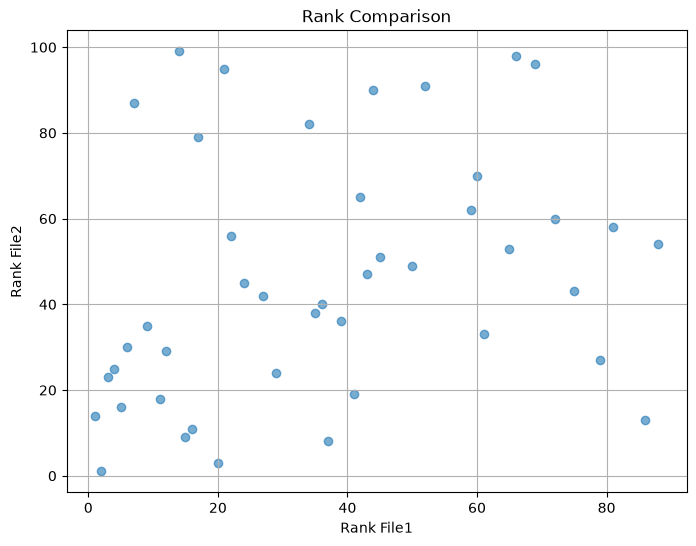

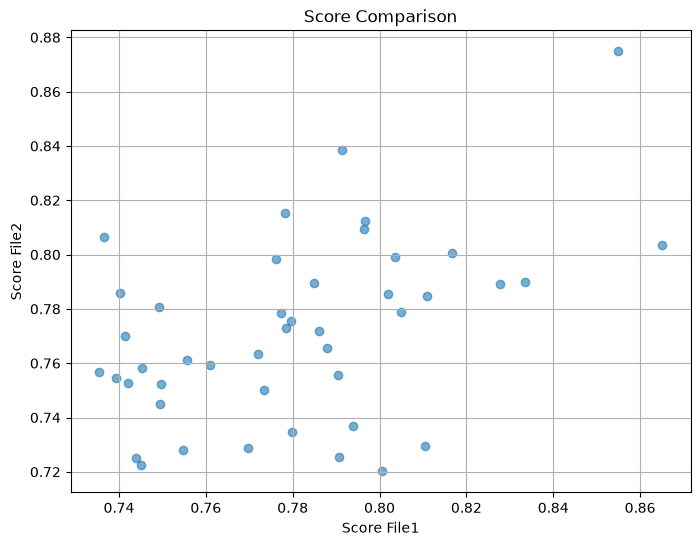

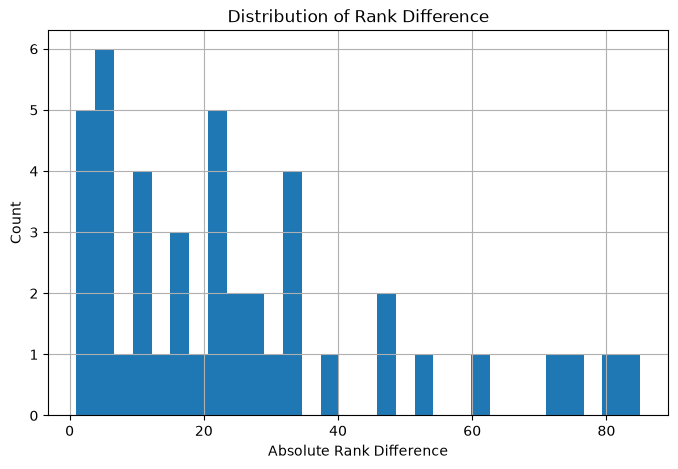

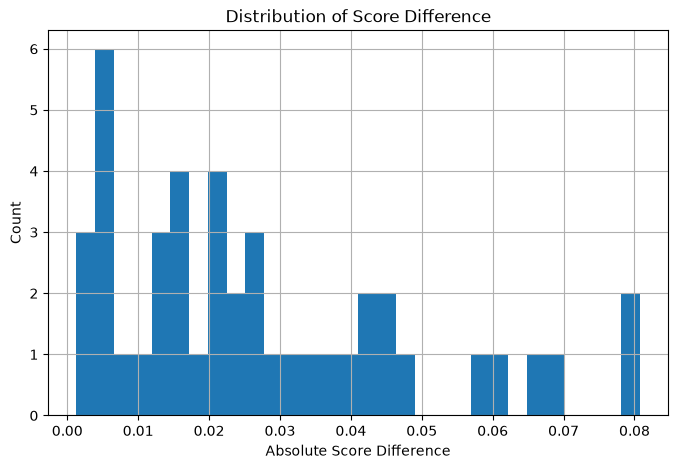


SUMMARY

Candidates compared      : 44

Candidate overlap        : 44

Average rank difference  : 25.23

Median rank difference   : 21.00

Average score difference : 0.027168

Score correlation        : 0.4572

Top-10 overlap           : 1

Top-25 overlap           : 9

Top-50 overlap           : 22

Top-100 overlap          : 44



: 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from difflib import SequenceMatcher
from sklearn.metrics import mean_absolute_error

# =====================================================
# CHANGE THESE PATHS
# =====================================================

FILE1 = "submission.csv"
FILE2 = "submission_friend.csv"

# =====================================================
# LOAD
# =====================================================

df1 = pd.read_csv(FILE1)
df2 = pd.read_csv(FILE2)

print("="*80)
print("FILE INFORMATION")
print("="*80)

print(f"File 1 : {FILE1}")
print(f"Rows    : {len(df1)}")

print()

print(f"File 2 : {FILE2}")
print(f"Rows    : {len(df2)}")

# =====================================================
# BASIC CHECKS
# =====================================================

print("\n" + "="*80)
print("COLUMN CHECK")
print("="*80)

print("File1 columns:", list(df1.columns))
print("File2 columns:", list(df2.columns))

common_cols = list(set(df1.columns) & set(df2.columns))

print("\nCommon Columns:")
print(common_cols)

# =====================================================
# EXACT FILE MATCH
# =====================================================

print("\n" + "="*80)
print("EXACT ROW COMPARISON")
print("="*80)

exact_rows = (
    df1.merge(df2, how="inner")
)

print("Exactly identical rows:", len(exact_rows))

# =====================================================
# CANDIDATE ANALYSIS
# =====================================================

set1 = set(df1["candidate_id"])
set2 = set(df2["candidate_id"])

common = set1 & set2
only1 = set1 - set2
only2 = set2 - set1

print("\n" + "="*80)
print("CANDIDATE ANALYSIS")
print("="*80)

print("Candidates File1 :", len(set1))
print("Candidates File2 :", len(set2))
print("Common           :", len(common))
print("Only File1       :", len(only1))
print("Only File2       :", len(only2))

print("\nCandidate Overlap: {:.2f}%".format(
    len(common)/max(len(set1),len(set2))*100
))

# =====================================================
# MERGE
# =====================================================

merged = pd.merge(
    df1,
    df2,
    on="candidate_id",
    suffixes=("_1","_2")
)

print("\nMerged Candidates:", len(merged))

# =====================================================
# RANK ANALYSIS
# =====================================================

print("\n" + "="*80)
print("RANK ANALYSIS")
print("="*80)

merged["rank_diff"] = (
    merged["rank_1"] - merged["rank_2"]
)

merged["abs_rank_diff"] = (
    merged["rank_diff"].abs()
)

print("Average Rank Difference:",
      round(merged["abs_rank_diff"].mean(),3))

print("Median Rank Difference:",
      round(merged["abs_rank_diff"].median(),3))

print("Maximum Rank Difference:",
      merged["abs_rank_diff"].max())

print("Perfect Rank Matches:",
      (merged["rank_diff"]==0).sum())

# =====================================================
# SCORE ANALYSIS
# =====================================================

print("\n" + "="*80)
print("SCORE ANALYSIS")
print("="*80)

merged["score_diff"] = (
    merged["score_1"] - merged["score_2"]
)

merged["abs_score_diff"] = (
    merged["score_diff"].abs()
)

print("Average Score Difference:",
      merged["abs_score_diff"].mean())

print("Maximum Score Difference:",
      merged["abs_score_diff"].max())

corr = merged["score_1"].corr(
    merged["score_2"]
)

print("Score Correlation:", corr)

mae = mean_absolute_error(
    merged["score_1"],
    merged["score_2"]
)

print("Score MAE:", mae)

# =====================================================
# TOP K OVERLAP
# =====================================================

print("\n" + "="*80)
print("TOP-K OVERLAP")
print("="*80)

for k in [10,25,50,100]:
    a = set(df1.nsmallest(k,"rank")["candidate_id"])
    b = set(df2.nsmallest(k,"rank")["candidate_id"])

    overlap = len(a & b)

    print(f"Top {k:<3} overlap : {overlap:>3}/{k} ({overlap/k*100:.2f}%)")

# =====================================================
# REASONING SIMILARITY
# =====================================================

print("\n" + "="*80)
print("REASONING SIMILARITY")
print("="*80)

if "reasoning_1" in merged.columns:

    similarities = []

    for a,b in zip(
        merged["reasoning_1"].fillna(""),
        merged["reasoning_2"].fillna("")
    ):

        similarities.append(
            SequenceMatcher(None,str(a),str(b)).ratio()
        )

    merged["reason_similarity"] = similarities

    print("Average Similarity:",
          np.mean(similarities))

    print("Median Similarity:",
          np.median(similarities))

    print("Identical Reasonings:",
          (merged["reason_similarity"]==1).sum())

# =====================================================
# HIGHEST RANK CHANGES
# =====================================================

print("\n" + "="*80)
print("TOP 20 BIGGEST RANK CHANGES")
print("="*80)

display(
    merged.sort_values(
        "abs_rank_diff",
        ascending=False
    )[[
        "candidate_id",
        "rank_1",
        "rank_2",
        "abs_rank_diff"
    ]].head(20)
)

# =====================================================
# SCORE DIFFERENCE
# =====================================================

print("\n" + "="*80)
print("TOP 20 BIGGEST SCORE CHANGES")
print("="*80)

display(
    merged.sort_values(
        "abs_score_diff",
        ascending=False
    )[[
        "candidate_id",
        "score_1",
        "score_2",
        "abs_score_diff"
    ]].head(20)
)

# =====================================================
# VISUALIZATIONS
# =====================================================

plt.figure(figsize=(8,6))
plt.scatter(
    merged["rank_1"],
    merged["rank_2"],
    alpha=0.6
)
plt.xlabel("Rank File1")
plt.ylabel("Rank File2")
plt.title("Rank Comparison")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(
    merged["score_1"],
    merged["score_2"],
    alpha=0.6
)
plt.xlabel("Score File1")
plt.ylabel("Score File2")
plt.title("Score Comparison")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.hist(
    merged["abs_rank_diff"],
    bins=30
)
plt.xlabel("Absolute Rank Difference")
plt.ylabel("Count")
plt.title("Distribution of Rank Difference")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.hist(
    merged["abs_score_diff"],
    bins=30
)
plt.xlabel("Absolute Score Difference")
plt.ylabel("Count")
plt.title("Distribution of Score Difference")
plt.grid(True)
plt.show()

# =====================================================
# SUMMARY
# =====================================================

print("\n" + "="*80)
print("SUMMARY")
print("="*80)

print(f"""
Candidates compared      : {len(merged)}

Candidate overlap        : {len(common)}

Average rank difference  : {merged['abs_rank_diff'].mean():.2f}

Median rank difference   : {merged['abs_rank_diff'].median():.2f}

Average score difference : {merged['abs_score_diff'].mean():.6f}

Score correlation        : {corr:.4f}

Top-10 overlap           : {len(set(df1.nsmallest(10,'rank')['candidate_id']) & set(df2.nsmallest(10,'rank')['candidate_id']))}

Top-25 overlap           : {len(set(df1.nsmallest(25,'rank')['candidate_id']) & set(df2.nsmallest(25,'rank')['candidate_id']))}

Top-50 overlap           : {len(set(df1.nsmallest(50,'rank')['candidate_id']) & set(df2.nsmallest(50,'rank')['candidate_id']))}

Top-100 overlap          : {len(set(df1.nsmallest(100,'rank')['candidate_id']) & set(df2.nsmallest(100,'rank')['candidate_id']))}
""")